## Aprendizaje No Supervisado

Los datos no tiene unan respuesta totalmente correcta.

El Experimento de hoy

K-Means ---> Divide los datos en K grupos diferentes y además de eso es quien encuentra esos mismo k grupos de eestudiantes con hábitos similares.

Método del codo ---> Elegir el número óptimo de clusters K

Silhuette Score ---> Medir qupe tan bien definidos están los clusters

PCA ( Principal Component Analysis ) ---> Reducir 14 dimensiones a 2 para poder visualizar los cluster

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

#CLustering
from sklearn.cluster import KMeans

#silhouette Score
from sklearn.metrics import silhouette_score

#Reducción de dimensiones
from sklearn.decomposition import PCA

#Preprocesamiento
from sklearn.preprocessing import StandardScaler, OrdinalEncoder

In [2]:
#Carga de datos y lectura

df = pd.read_csv("student_habits_performance.csv")

df = df.drop(columns=['student_id'])

df.head()


,age,gender,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,diet_quality,exercise_frequency,parental_education_level,internet_quality,mental_health_rating,extracurricular_participation,exam_score
0,23,Female,0.0,1.2,1.1,No,85.0,8.0,Fair,6,Master,Average,8,Yes,56.2
1,20,Female,6.9,2.8,2.3,No,97.3,4.6,Good,6,High School,Average,8,No,100.0
2,21,Male,1.4,3.1,1.3,No,94.8,8.0,Poor,1,High School,Poor,1,No,34.3
3,23,Female,1.0,3.9,1.0,No,71.0,9.2,Poor,4,Master,Good,1,Yes,26.8
4,19,Female,5.0,4.4,0.5,No,90.9,4.9,Fair,3,Master,Good,1,No,66.4


In [3]:
#Guardar las etiquetas reales antes de que el modelo las vea
exam_score_real = df['exam_score'].copy()
aprueba_real = (df['exam_score'] >=60).astype(int)

#Eliminar las targets
df = df.drop(columns=['exam_score'])



In [4]:
#Tratamiento de nulos
moda_educacion = df['parental_education_level'].mode()[0]
df['parental_education_level'] = df['parental_education_level'].fillna(moda_educacion)

# Encoding de variables categóricas
#diet_quality
oe_diet = OrdinalEncoder(categories=[['Poor', 'Fair', 'Good']])
df['diet_quality'] = oe_diet.fit_transform(df[['diet_quality']]).reshape(-1)

#internet_quality
oe_net = OrdinalEncoder(categories=[['Poor', 'Average', 'Good']])
df['internet_quality'] = oe_net.fit_transform(df[['internet_quality']]).reshape(-1)

#parental_education_level
oe_edu = OrdinalEncoder(categories=[['High School', 'Bachelor', 'Master']])
df['parental_education_level'] = oe_edu.fit_transform(df[['parental_education_level']]).reshape(-1)

#--Encoding binario para variables Yes/No
df['part_time_job'] = (df['part_time_job'] =='Yes').astype(int)
df['extracurricular_participation'] = (df['extracurricular_participation'] =='Yes').astype(int)

#--One Hot Encoding para gender (nominal, sin orden)

#Crear una columna binaria por cata categoría de genero
df = pd.get_dummies(df, columns=['gender'], drop_first=True, dtype=int)

#Escalado de los datos
scaler = StandardScaler()

X_scaled = scaler.fit_transform(df)

#verficación después del escalado
print(f'Dataset listo para clustering:')
print(f'Estudiantes: {X_scaled.shape[0]} | Features: {X_scaled.shape[1]}')
print(f' Media global:  {X_scaled.mean():.6f} (debe ser aproximadamente 0)')
print(f' Std global: | {X_scaled.std():.6f} (debe ser aproximadamente 1)')

Dataset listo para clustering:
Estudiantes: 1000 | Features: 15
 Media global:  -0.000000 (debe ser aproximadamente 0)
 Std global: | 1.000000 (debe ser aproximadamente 1)


In [21]:
#Evaluar k_Means para K desde 1 hasta 10 cluster

k_valores   = range(1, 11) #valores de K a probar
inercias    = []
silhouettes = []

for k in k_valores:
    
    kmeans_k = KMeans(n_clusters=k, n_init=10, max_iter=300, random_state=42)
    
    labels_k = kmeans_k.fit_predict(X_scaled)
    
    # con k=1 es máxima (todos en un grupo); con k=N es 0 (cada punto es su propio cluster)
    inercias.append(kmeans_k.inertia_)           
    
    if k >= 2:
        silhouettes.append(silhouette_score(X_scaled, labels_k))
    else:
        silhouettes.append(None)

#Tabla resumen con inercia y silhouette score de cada k
print('K | Inercia        | Silhouette')
print('-' * 35)
for k, ine, sil in zip(k_valores, inercias, silhouettes):
    sil_str = f'{sil:.4f}' if sil is not None else 'N/A'
    print(f'{k:2} | {ine:10.1f} | {sil_str}')


K | Inercia        | Silhouette
-----------------------------------
 1 |    15000.0 | N/A
 2 |    13947.4 | 0.0708
 3 |    13166.3 | 0.0734
 4 |    12380.3 | 0.0766
 5 |    11847.1 | 0.0691
 6 |    11421.6 | 0.0694
 7 |    11221.8 | 0.0606
 8 |    10952.2 | 0.0688
 9 |    10790.0 | 0.0719
10 |    10620.6 | 0.0684


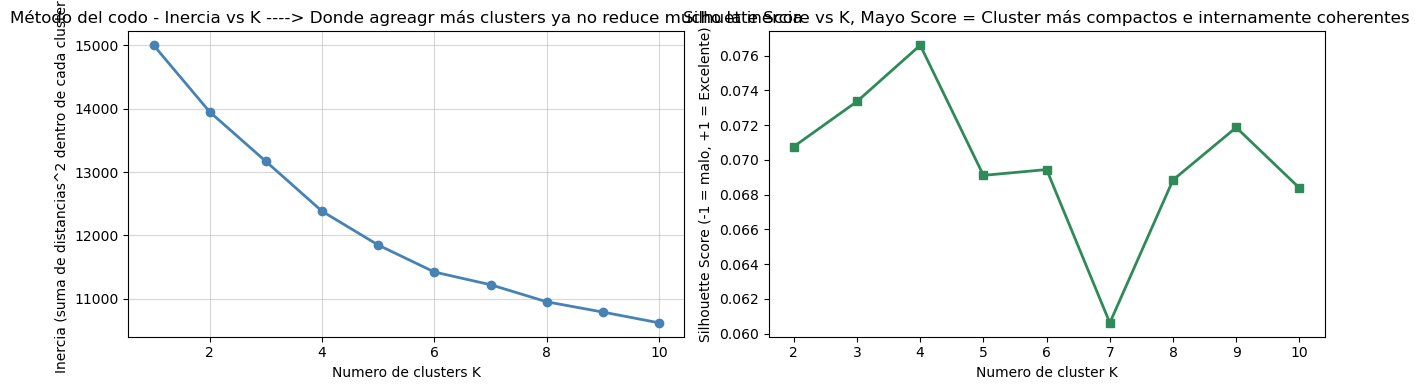

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(k_valores, inercias, marker='o', color='steelblue', linewidth=2, markersize=6)
axes[0].set_title('Método del codo - Inercia vs K ----> Donde agreagr más clusters ya no reduce mucho la inercia')

axes[0].set_xlabel('Numero de clusters K')
axes[0].set_ylabel('Inercia (suma de distancias^2 dentro de cada cluster)')
axes[0].grid(alpha=0.5)


#Panel derecho

k_vals_sil = list(k_valores)[1:]
sill_vals = silhouettes[1:]

axes[1].plot(k_vals_sil, sill_vals, marker='s', color='seagreen', linewidth=2, markersize=6)
axes[1].set_title('Silhuette Score vs K, Mayo Score = Cluster más compactos e internamente coherentes')

axes[1].set_xlabel('Numero de cluster K')
axes[1].set_ylabel('Silhouette Score (-1 = malo, +1 = Excelente)')
axes[0].grid(alpha=0.5)

plt.tight_layout()


plt.show()

In [14]:
K_OPTIMO = 3

kmeans = KMeans(
    n_clusters=K_OPTIMO,  #Numero de grupos a encontrar en los datos
    n_init=10,
    max_iter=300,
    random_state=42
)

etiquetas_cluster = kmeans.fit_predict(X_scaled)

df['cluster'] = etiquetas_cluster

print(f'K-Means entrenado con K={K_OPTIMO} clusters')
print(f'Inercial final:         {kmeans.inertia_:2f}')
print(f'Silhouette Score:       {silhouette_score(X_scaled, etiquetas_cluster):.4f}')
print(f'iteraciones hasta convergencias: {kmeans.n_iter_}')
print()
print('Distribución de estudiantes por cluster: ')
for k in range(K_OPTIMO):
    n = (etiquetas_cluster == k).sum()
    pct = n / len(etiquetas_cluster)
    print(f'Cluster {k}: {n} estudiantes ({pct:.1%})')



K-Means entrenado con K=3 clusters
Inercial final:         13166.347371
Silhouette Score:       0.0734
iteraciones hasta convergencias: 16

Distribución de estudiantes por cluster: 
Cluster 0: 215 estudiantes (21.5%)
Cluster 1: 368 estudiantes (36.8%)
Cluster 2: 417 estudiantes (41.7%)


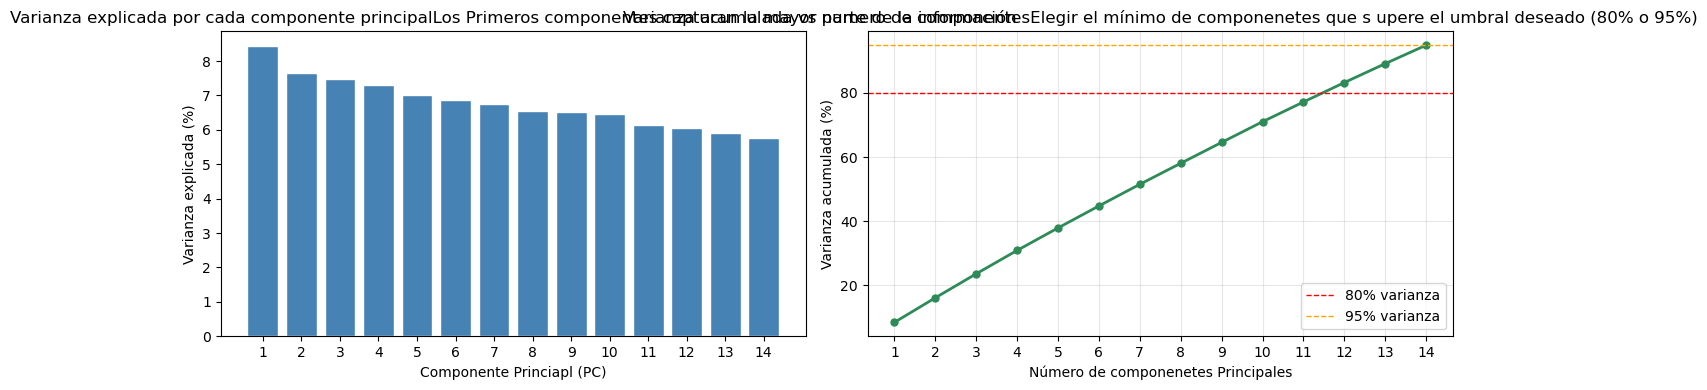

In [30]:
#PCA 
pca_completo = PCA(n_components=14, random_state=42)

pca_completo.fit_transform(X_scaled)

varianza_por_componente = pca_completo.explained_variance_ratio_

varianza_acumulada = np.cumsum(varianza_por_componente)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

#Panel Izquierdo
componentes_idx = range(1, 15)

axes[0].bar(componentes_idx, varianza_por_componente * 100, color ='steelblue', edgecolor='white')

axes[0].set_title('Varianza explicada por cada componente principal'
                  'Los Primeros componentes capturan la mayor parte de la información'
                  )

axes[0].set_xlabel('Componente Princiapl (PC)')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_xticks(componentes_idx) #mostrarnos todos los numeros de l 1-14


#Panel derecho

axes[1].plot(componentes_idx, varianza_acumulada * 100, marker='o', color ='seagreen', linewidth = 2, markersize=5)

#Liena de referencia
axes[1].axhline(80, color= 'red', linestyle='--', linewidth=1, label='80% varianza')
axes[1].axhline(95, color= 'orange', linestyle='--', linewidth=1, label='95% varianza')

axes[1].set_title('Varianza acumulada vs numero de componentes'
                  'Elegir el mínimo de componenetes que s upere el umbral deseado (80% o 95%)'
                  )

axes[1].set_xlabel('Número de componenetes Principales')
axes[1].set_ylabel('Varianza acumulada (%)')
axes[1].legend()
axes[1].set_xticks(componentes_idx) #mostrarnos todos los numeros de l 1-14
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [31]:
#PCA con 2 componenete

pcs_2d = PCA(n_components=2, random_state=42)

X_pca = pcs_2d.fit_transform(X_scaled)

varianza_2d = pcs_2d.explained_variance_ratio_.sum()

print(f'Varianza total capturada con 2 componentes: {varianza_2d:.1%}')
print(f'Información "perdida" en la compresión: {(1- varianza_2d):.1%}')
print()

print(f'PC1 explica: {pcs_2d.explained_variance_ratio_[0]:.1%} de la varianza total')
print(f'PC2 explica: {pcs_2d.explained_variance_ratio_[1]:.1%} de la varianza total')
print()
print(f'Los 1000 estudiantes ahora viven en un espacio 2D: {X_pca.shape}')


Varianza total capturada con 2 componentes: 16.1%
Información "perdida" en la compresión: 83.9%

PC1 explica: 8.4% de la varianza total
PC2 explica: 7.7% de la varianza total

Los 1000 estudiantes ahora viven en un espacio 2D: (1000, 2)


## ¿Cuanta varianza explica cada componente?
